<a href="https://colab.research.google.com/github/juanflo-svg/origami_quality_control/blob/main/Copia_de_datos_RadioInterno_simulados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



PARÁMETROS DEL DISEÑO
μ = 61.3580 mm        σ = 1.1560 mm
n = 5              m = 25
L = 2.5             α = 0.0124
ARL₀ = 80.5
Δ = 0.0·σ = 0.0000 mm
Potencia (1-β) = 0.0124
Tipo de cambio: sostenido desde subgrupo 18


RESULTADOS CARTA X̄
x̄̄  = 61.3554 mm
LCS = 62.6475 mm
LCI = 60.0633 mm
Puntos fuera de control: 8


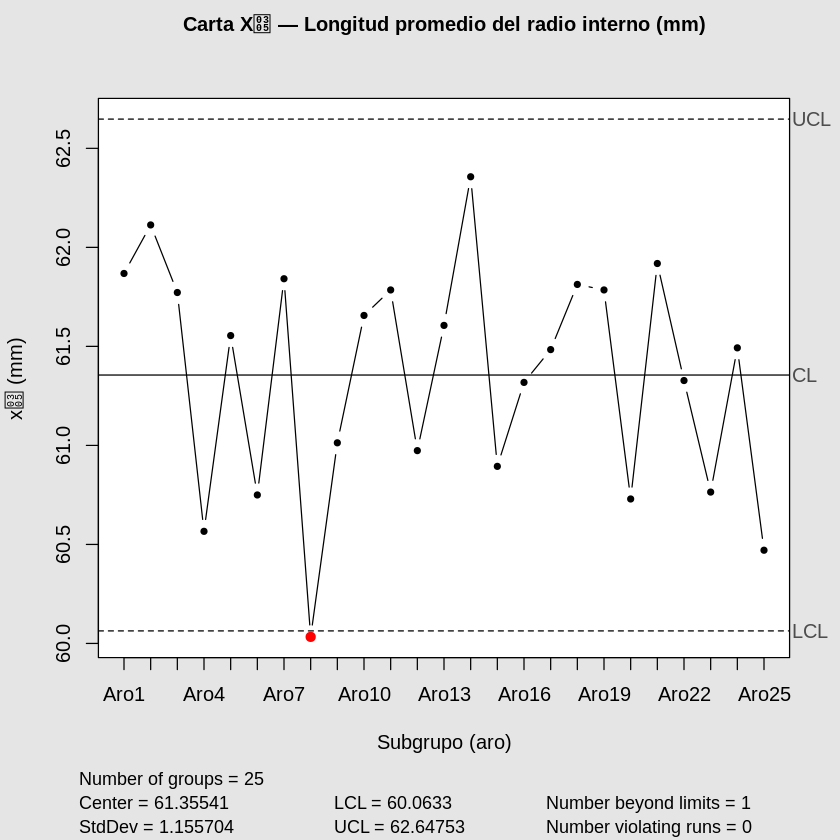


RESULTADOS CARTA R
R̄   = 2.6882 mm
LCS = 5.1847 mm
LCI = 0.1916 mm
Puntos fuera de control: ninguno

RESUMEN DEL ESTUDIO
Total aros inspeccionados : 125
Subgrupos en control X̄   : 24 / 25
Subgrupos en control R    : 25 / 25

Causa asignable detectada en subgrupo(s): 8
Subgrupos desde cambio simulado        : -10


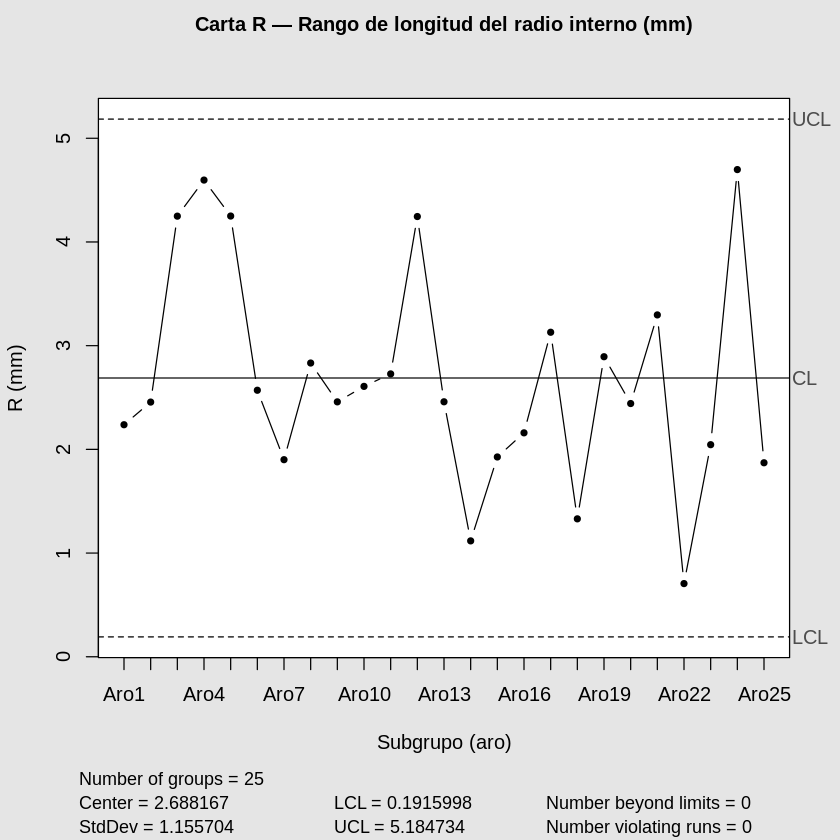

In [ ]:
# Instalar y cargar qcc
install.packages("qcc")
library(qcc)

# ============================================================
# PARÁMETROS MODIFICABLES
# ============================================================

# -- Parámetros del proceso (estimados de la premuestra) --
mu    <- 61.358   # Media del proceso (mm)
sigma <- 1.156    # Desviación estándar (mm)

# -- Diseño de la carta --
n  <- 5           # Tamaño del subgrupo
m  <- 25          # Número de subgrupos
L  <- 2.5         # Límite en sigmas (estándar Montgomery: 3)

# -- Causa asignable --
subgrupo_cambio <- 18      # Subgrupo desde donde ocurre el cambio
magnitud_cambio <- 0     # En múltiplos de sigma
tipo_cambio     <- "sostenido"  # "sostenido" o "puntual"

# -- Semilla --
set.seed(42)

# ============================================================
# SIMULACIÓN DE DATOS
# ============================================================

datos <- matrix(NA, nrow = m, ncol = n)

for (i in 1:m) {
  if (tipo_cambio == "sostenido" && i >= subgrupo_cambio) {
    mu_i <- mu + magnitud_cambio * sigma
  } else if (tipo_cambio == "puntual" && i == subgrupo_cambio) {
    mu_i <- mu + magnitud_cambio * sigma
  } else {
    mu_i <- mu
  }
  datos[i, ] <- rnorm(n, mean = mu_i, sd = sigma)
}

rownames(datos) <- paste0("Aro", 1:m)

# ============================================================
# PARÁMETROS ESTADÍSTICOS
# ============================================================

alpha    <- 2 * (1 - pnorm(L))
ARL0     <- 1 / alpha
delta    <- magnitud_cambio * sigma
arg1     <- L - magnitud_cambio * sqrt(n)
arg2     <- -L - magnitud_cambio * sqrt(n)
potencia <- pnorm(arg2) + (1 - pnorm(arg1))

cat("============================================================\n")
cat("PARÁMETROS DEL DISEÑO\n")
cat("============================================================\n")
cat(sprintf("μ = %.4f mm        σ = %.4f mm\n", mu, sigma))
cat(sprintf("n = %d              m = %d\n", n, m))
cat(sprintf("L = %.1f             α = %.4f\n", L, alpha))
cat(sprintf("ARL₀ = %.1f\n", ARL0))
cat(sprintf("Δ = %.1f·σ = %.4f mm\n", magnitud_cambio, delta))
cat(sprintf("Potencia (1-β) = %.4f\n", potencia))
cat(sprintf("Tipo de cambio: %s desde subgrupo %d\n\n",
            tipo_cambio, subgrupo_cambio))

# ============================================================
# CARTA X̄ con qcc
# ============================================================

carta_xbar <- qcc(
  data     = datos,
  type     = "xbar",
  nsigmas  = L,
  title    = "Carta X\u0305 \u2014 Longitud promedio del radio interno (mm)",
  xlab     = "Subgrupo (aro)",
  ylab     = "x\u0305 (mm)",
  add.stats = TRUE
)

cat("\n============================================================\n")
cat("RESULTADOS CARTA X̄\n")
cat("============================================================\n")
cat(sprintf("x̄̄  = %.4f mm\n", carta_xbar$center))
cat(sprintf("LCS = %.4f mm\n", carta_xbar$limits[2]))
cat(sprintf("LCI = %.4f mm\n", carta_xbar$limits[1]))
puntos_xbar <- carta_xbar$violations$beyond.limits
cat(sprintf("Puntos fuera de control: %s\n",
            ifelse(length(puntos_xbar) == 0, "ninguno",
                   paste(puntos_xbar, collapse = ", "))))

# ============================================================
# CARTA R con qcc
# ============================================================

carta_R <- qcc(
  data     = datos,
  type     = "R",
  nsigmas  = L,
  title    = "Carta R \u2014 Rango de longitud del radio interno (mm)",
  xlab     = "Subgrupo (aro)",
  ylab     = "R (mm)",
  add.stats = TRUE
)

cat("\n============================================================\n")
cat("RESULTADOS CARTA R\n")
cat("============================================================\n")
cat(sprintf("R̄   = %.4f mm\n", carta_R$center))
cat(sprintf("LCS = %.4f mm\n", carta_R$limits[2]))
cat(sprintf("LCI = %.4f mm\n", carta_R$limits[1]))
puntos_R <- carta_R$violations$beyond.limits
cat(sprintf("Puntos fuera de control: %s\n",
            ifelse(length(puntos_R) == 0, "ninguno",
                   paste(puntos_R, collapse = ", "))))

# ============================================================
# RESUMEN FINAL
# ============================================================

cat("\n============================================================\n")
cat("RESUMEN DEL ESTUDIO\n")
cat("============================================================\n")
cat(sprintf("Total aros inspeccionados : %d\n", m * n))
cat(sprintf("Subgrupos en control X̄   : %d / %d\n",
            m - length(puntos_xbar), m))
cat(sprintf("Subgrupos en control R    : %d / %d\n",
            m - length(puntos_R), m))
if (length(puntos_xbar) > 0) {
  cat(sprintf("\nCausa asignable detectada en subgrupo(s): %s\n",
              paste(puntos_xbar, collapse = ", ")))
  cat(sprintf("Subgrupos desde cambio simulado        : %d\n",
              min(puntos_xbar) - subgrupo_cambio))
}

In [ ]:
datos

Aro1,62.94283,60.70521,61.77778,62.08959,61.82533
Aro2,61.23532,63.10532,61.24857,63.69130,61.28550
Aro3,62.86643,64.00136,59.75248,61.03572,61.20388
Aro4,62.09316,61.02940,58.28714,58.53682,62.88405
Aro5,61.00353,59.29881,61.15926,62.76216,63.54884
Aro6,60.86038,61.06060,59.31978,61.88987,60.61817
Aro7,61.88450,62.17279,62.55458,60.65408,61.94173
Aro8,59.37314,60.45117,60.37435,58.56718,61.39976
Aro9,61.59613,60.94062,62.23444,60.51793,59.77627
Aro10,61.85834,60.42003,63.02738,60.85925,62.11593
Aro11,61.73015,60.45188,63.17954,62.10119,61.46176
